# 신용카드 사기 거래 탐지 (Credit Card Fraud Detection)

## 프로젝트 개요
Kaggle의 Credit Card Fraud Detection 데이터셋을 활용하여 딥러닝 기반의 이진 분류 모델을 개발한다.
데이터는 2013년 9월 유럽 신용카드 거래 데이터로, 284,807건 중 492건(약 0.17%)만이 사기 거래이다.  
클래스 불균형(class imbalance)을 다루는 방법과 다양한 하이퍼파라미터 실험을 통해 최적 모델을 선정한다.

## 전체 파이프라인
1. 데이터 로드
2. EDA
3. 전처리 (스케일링 + 클래스 가중치)
4. 학습/검증/테스트 분할
5. 베이스 모델 정의
6. 하이퍼파라미터 실험 (5회)
7. 최종 모델 학습 및 저장
8. 테스트셋 평가 및 해석

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score
)

warnings.filterwarnings('ignore')

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':  # macOS
    matplotlib.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지

---
## 1. 데이터 로드
- `Time` &nbsp;&nbsp;&nbsp;: 거래로부터 경과 시간(초)
- `Amount`: 거래 금액
- `V1~V28`: PCA 변환된 익명 피처
- `Class` &nbsp;: 0 = 정상, 1 = 사기

In [54]:
DATA_PATH = 'data/creditcard.csv'
df = pd.read_csv(DATA_PATH)

# 데이터 기본 정보 출력
print('=== 데이터 크기 (행, 열) ===')
print(df.shape)
print()

print('=== 상위 5행 미리보기 ===')
print(df.head())
print()

print('=== 클래스 분포 (Class: 0=정상, 1=사기) ===')
print(df['Class'].value_counts())
print()

=== 데이터 크기 (행, 열) ===
(284807, 31)

=== 상위 5행 미리보기 ===
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  

---
## 2. EDA

신용카드 사기 탐지에서는 **클래스 불균형이 매우 심각**하기 때문에 
단순 정확도(Accuracy)만으로는 모델 성능을 평가할 수 없다.

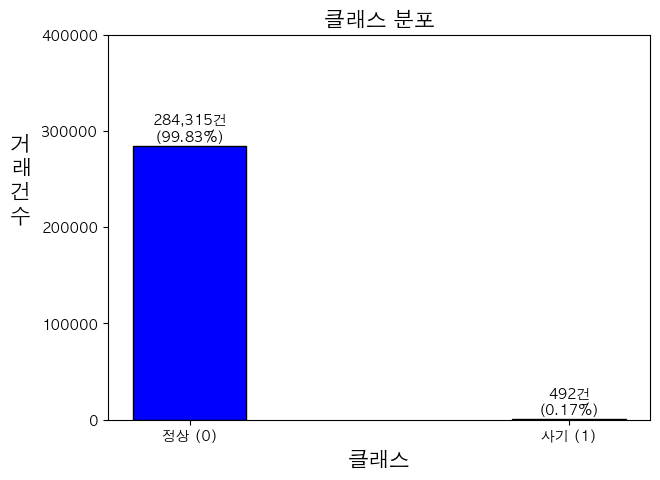

클래스 불균형 비율 — 정상:284,315 | 사기:492
사기 거래 비율: 0.1727%


In [55]:
# 클래스 불균형 시각화
class_counts = df['Class'].value_counts()
class_labels = ['정상 (0)', '사기 (1)']
total = len(df)

fig, ax = plt.subplots(figsize=(7, 5))

# 막대 그래프 생성
bars = ax.bar(
    class_labels,
    [class_counts[0], class_counts[1]],
    color=['blue', 'red'],
    edgecolor='black',
    width=0.3
)

# 막대 위에 건수 및 비율 표기
for bar, count in zip(bars, [class_counts[0], class_counts[1]]):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2, # 막대 중앙
        bar.get_height() + 1500,           # 막대 위 텍스트 위치
        f'{count:,}건\n({pct:.2f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('클래스 분포', fontsize=15)
ax.set_xlabel('클래스', fontsize=15)
ax.set_ylabel('거\n래\n건\n수', fontsize=15, rotation=0, labelpad=15)
ax.set_yticks([0, 100000, 200000, 300000, 400000])
plt.show()

print(f'클래스 불균형 비율 — 정상:{class_counts[0]:,} | 사기:{class_counts[1]:,}')
print(f'사기 거래 비율: {class_counts[1]/total*100:.4f}%')

In [56]:
# 통계 출력
print('=== 전체 데이터 통계량 ===')
print(df.describe().T.to_string())  # 전치하여 가독성 향상

=== 전체 데이터 통계량 ===
           count          mean           std         min           25%           50%            75%            max
Time    284807.0  9.481386e+04  47488.145955    0.000000  54201.500000  84692.000000  139320.500000  172792.000000
V1      284807.0  1.175161e-15      1.958696  -56.407510     -0.920373      0.018109       1.315642       2.454930
V2      284807.0  3.384974e-16      1.651309  -72.715728     -0.598550      0.065486       0.803724      22.057729
V3      284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365      0.179846       1.027196       9.382558
V4      284807.0  2.094852e-15      1.415869   -5.683171     -0.848640     -0.019847       0.743341      16.875344
V5      284807.0  1.021879e-15      1.380247 -113.743307     -0.691597     -0.054336       0.611926      34.801666
V6      284807.0  1.494498e-15      1.332271  -26.160506     -0.768296     -0.274187       0.398565      73.301626
V7      284807.0 -5.620335e-16      1.237094  -43.557242     

---
## 3. 전처리

**스케일링:**  
`Amount`(거래 금액)와 `Time`(경과 시간)은 다른 피처(`V1~V28`)와 스케일이 다르다.
딥러닝 모델은 입력 값의 크기에 민감하므로, `MinMaxScaler`로 정규화한다.    
`V1~V28`은 이미 PCA 변환되어 표준화된 상태이므로 추가 스케일링이 불필요하다.

**클래스 가중치:**
정상 거래가 사기 거래보다 약 577배 많다.    
`compute_class_weight('balanced')`를 사용하면 소수 클래스(사기)에 더 높은 가중치를 부여하여
모델이 사기 거래를 더 중요하게 학습하도록 유도한다.

In [57]:
# Amount와 Time에 MinMaxScaler 적용
# 복사본 사용
df_processed = df.copy()

scaler = MinMaxScaler()

df_processed[['Amount', 'Time']] = scaler.fit_transform(df_processed[['Amount', 'Time']])

print('=== 스케일링 후 Amount, Time 범위 확인 ===')
print(f"Amount — min: {df_processed['Amount'].min():.4f}, max: {df_processed['Amount'].max():.4f}")
print(f"Time   — min: {df_processed['Time'].min():.4f}, max: {df_processed['Time'].max():.4f}")

=== 스케일링 후 Amount, Time 범위 확인 ===
Amount — min: 0.0000, max: 1.0000
Time   — min: 0.0000, max: 1.0000


In [58]:
# 피처(X)와 레이블(y) 분리
X = df_processed.drop(columns=['Class']).values  # numpy 배열로 변환
y = df_processed['Class'].values

print(f'X: {X.shape}')
print(f'y: {y.shape}')

X: (284807, 30)
y: (284807,)


In [59]:
# 클래스 가중치 계산
# compute_class_weight('balanced')는 클래스 빈도에 반비례하는 가중치를 계산
# 공식: w_j = n_samples / (n_classes * n_samples_j)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

# Keras가 요구하는 딕셔너리 형태로 변환
class_weight_dict = {
    0: class_weights_array[0],  # 정상 거래 가중치
    1: class_weights_array[1]   # 사기 거래 가중치
}

print('=== 클래스 가중치 ===')
print(f"정상 거래 (0): {class_weight_dict[0]:.4f}")
print(f"사기 거래 (1): {class_weight_dict[1]:.4f}")
print(f"\n가중치 비율 (사기/정상): {class_weight_dict[1]/class_weight_dict[0]:.1f}배")
print("→ 사기 거래 1건의 손실이 정상 거래보다 훨씬 크게 반영됨")

=== 클래스 가중치 ===
정상 거래 (0): 0.5009
사기 거래 (1): 289.4380

가중치 비율 (사기/정상): 577.9배
→ 사기 거래 1건의 손실이 정상 거래보다 훨씬 크게 반영됨


---
## 4. 학습 / 검증 / 테스트 분할

- **학습셋 (Train, 60%)**: 모델 파라미터를 업데이트하는 데 사용
- **검증셋 (Validation, 20%)**: 하이퍼파라미터 튜닝 및 EarlyStopping 기준으로 사용
- **테스트셋 (Test, 20%)**: 최종 성능 평가에만 사용

In [60]:
# 전체 → 학습 + 검증(80%) / 테스트(20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# 학습 + 검증 → 학습(75%) / 검증(25%)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval)

print('=== 데이터 분할 결과 ===')
print(f'X_train: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)')
print(f'X_val  : {X_val.shape}   ({len(X_val)/len(X)*100:.1f}%)')
print(f'X_test : {X_test.shape}  ({len(X_test)/len(X)*100:.1f}%)')
print()

# 각 셋의 클래스 비율 확인 (stratify 적용 확인)
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    fraud_pct = y_split.mean() * 100
    print(f'{name} 사기 비율: {fraud_pct:.4f}%')

=== 데이터 분할 결과 ===
X_train: (170883, 30) (60.0%)
X_val  : (56962, 30)   (20.0%)
X_test : (56962, 30)  (20.0%)

Train 사기 비율: 0.1726%
Val 사기 비율: 0.1738%
Test 사기 비율: 0.1720%


---
## 6. 하이퍼파라미터 실험

각 셀에서 **하나의 값만** 여러 후보로 바꾸고 나머지는 고정한다.  
이전 셀의 최적값이 다음 셀에 누적되어 최적 조합을 찾는다.

### 6-1. 활성화 함수 비교
고정: units=32, lr=0.001, dropout=0.3, batch=512

In [67]:
act_results = []

for act in ['relu', 'tanh', 'sigmoid']:
    model = Sequential()

    model.add(Dense(32, activation=act, input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation=act))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])

    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=100, batch_size=512, class_weight=class_weight_dict,
              callbacks=[EarlyStopping(monitor='val_auc', patience=5,
                                       restore_best_weights=True, mode='max', verbose=0)],
              verbose=0)

    loss, acc, auc, prec, rec = model.evaluate(X_test, y_test, verbose=0)
    act_results.append({'activation': act, 'accuracy': round(acc, 4),
                        'AUC': round(auc, 4), 'precision': round(prec, 4),
                        'recall': round(rec, 4)})

result_df = pd.DataFrame(act_results)
print(result_df.to_string(index=False))

best_activation = result_df.loc[result_df['AUC'].idxmax(), 'activation']
print(f'\n★ best activation: {best_activation}')


activation  accuracy    AUC  precision  recall
      relu    0.9780 0.9643     0.0648  0.8776
      tanh    0.9758 0.9783     0.0610  0.9082
   sigmoid    0.9932 0.9709     0.1846  0.8571

★ best activation: tanh


### 6-2. 학습률 비교
고정: best_activation, units=32, dropout=0.3, batch=512

In [68]:
lr_results = []

for lr in [0.01, 0.001, 0.0001, 0.00001]:
    model = Sequential()

    model.add(Dense(32, activation=best_activation, input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation=best_activation))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])
                           
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=100, batch_size=512, class_weight=class_weight_dict,
              callbacks=[EarlyStopping(monitor='val_auc', patience=5,
                                       restore_best_weights=True, mode='max', verbose=0)],
              verbose=0)
    
    loss, acc, auc, prec, rec = model.evaluate(X_test, y_test, verbose=0)
    lr_results.append({'lr': lr, 'accuracy': round(acc, 4),
                       'AUC': round(auc, 4), 'precision': round(prec, 4),
                       'recall': round(rec, 4)})

result_df = pd.DataFrame(lr_results)
print(result_df.to_string(index=False))

best_lr = float(result_df.loc[result_df['AUC'].idxmax(), 'lr'])
print(f'\n★ best lr: {best_lr}')

     lr  accuracy    AUC  precision  recall
0.01000    0.9459 0.9809     0.0287  0.9286
0.00100    0.9689 0.9779     0.0485  0.9184
0.00010    0.9686 0.9748     0.0466  0.8878
0.00001    0.9596 0.9683     0.0373  0.9082

★ best lr: 0.01


### 6-3. 배치 크기 비교
고정: best_activation, best_lr, dropout=0.3

In [69]:
bs_results = []

for bs in [256, 512, 1024, 2048]:
    model = Sequential()

    model.add(Dense(32, activation=best_activation, input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation=best_activation))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(best_lr), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])
    
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=100, batch_size=bs, class_weight=class_weight_dict,
              callbacks=[EarlyStopping(monitor='val_auc', patience=5,
                                       restore_best_weights=True, mode='max', verbose=0)],
              verbose=0)
    
    loss, acc, auc, prec, rec = model.evaluate(X_test, y_test, verbose=0)
    bs_results.append({'batch_size': bs, 'accuracy': round(acc, 4),
                       'AUC': round(auc, 4), 'precision': round(prec, 4),
                       'recall': round(rec, 4)})

result_df = pd.DataFrame(bs_results)
print(result_df.to_string(index=False))

best_batch = int(result_df.loc[result_df['AUC'].idxmax(), 'batch_size'])
print(f'\n★ best batch_size: {best_batch}')

 batch_size  accuracy    AUC  precision  recall
        256    0.9774 0.9774     0.0651  0.9082
        512    0.9386 0.9747     0.0257  0.9388
       1024    0.9824 0.9769     0.0814  0.8980
       2048    0.9708 0.9766     0.0515  0.9184

★ best batch_size: 256


### 6-4. 드롭아웃 비율 비교
고정: best_activation, best_lr, best_batch

In [70]:
do_results = []

for dr in [0.1, 0.2, 0.3, 0.5]:
    model = Sequential()

    model.add(Dense(32, activation=best_activation, input_shape=(X_train.shape[1],)))
    model.add(Dropout(dr))
    model.add(Dense(32, activation=best_activation))
    model.add(Dropout(dr))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(best_lr), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])
    
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=100, batch_size=best_batch, class_weight=class_weight_dict,
              callbacks=[EarlyStopping(monitor='val_auc', patience=5,
                                       restore_best_weights=True, mode='max', verbose=0)],
              verbose=0)
    
    loss, acc, auc, prec, rec = model.evaluate(X_test, y_test, verbose=0)
    do_results.append({'dropout': dr, 'accuracy': round(acc, 4),
                       'AUC': round(auc, 4), 'precision': round(prec, 4),
                       'recall': round(rec, 4)})

result_df = pd.DataFrame(do_results)
print(result_df.to_string(index=False))

best_dropout = float(result_df.loc[result_df['AUC'].idxmax(), 'dropout'])
print(f'\n★ best dropout: {best_dropout}')

 dropout  accuracy    AUC  precision  recall
     0.1    0.9474 0.9775     0.0292  0.9184
     0.2    0.9666 0.9825     0.0458  0.9286
     0.3    0.9639 0.9744     0.0403  0.8776
     0.5    0.9811 0.9824     0.0764  0.8980

★ best dropout: 0.2


In [71]:
print('=== 최종 하이퍼파라미터 조합 ===')
print(f'  activation  : {best_activation}')
print(f'  learning_rate: {best_lr}')
print(f'  batch_size  : {best_batch}')
print(f'  dropout_rate: {best_dropout}')

=== 최종 하이퍼파라미터 조합 ===
  activation  : tanh
  learning_rate: 0.01
  batch_size  : 256
  dropout_rate: 0.2


---
## 7. 최종 모델 학습 및 저장

각 실험에서 찾은 최적값 조합으로 **train + val** 전체를 사용해 재학습한 뒤 저장한다.

In [73]:
X_tv = np.concatenate([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

final_model = Sequential()

final_model.add(Dense(32, activation=best_activation))
final_model.add(Dropout(best_dropout))
final_model.add(Dense(32, activation=best_activation))
final_model.add(Dropout(best_dropout))
final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(optimizer=Adam(best_lr), loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

final_hist = final_model.fit(X_tv, y_tv, validation_data=(X_val, y_val), epochs=100, batch_size=best_batch, class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1)], verbose=0
)

final_model.save('best_fraud_model.keras')
print('모델 저장 완료: best_fraud_model.keras')

Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
모델 저장 완료: best_fraud_model.keras


---
## 8. 테스트셋 평가 및 해석  

In [74]:
# 저장된 모델 로드 및 테스트셋 평가
# 저장된 .keras 파일에서 모델 로드
loaded_model = tf.keras.models.load_model('best_fraud_model.keras')
print('모델 로드 완료')

# Keras evaluate: loss, accuracy, auc, precision, recall 반환
test_scores = loaded_model.evaluate(X_test, y_test, verbose=0)
metric_names = loaded_model.metrics_names

print('\n=== Keras evaluate 결과 (테스트셋) ===')
for name, score in zip(metric_names, test_scores):
    print(f'  {name}: {score:.4f}')

모델 로드 완료

=== Keras evaluate 결과 (테스트셋) ===
  loss: 0.1132
  compile_metrics: 0.9893


In [75]:
# -------------------------------------------------------
# 8-2. 예측값 생성 및 sklearn 지표 계산
# -------------------------------------------------------
# 확률값 예측 (0~1 사이의 실수)
y_pred_prob = loaded_model.predict(X_test, verbose=0).flatten()

# 임계값 0.5로 이진 분류
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# sklearn으로 상세 지표 계산
acc       = accuracy_score(y_test, y_pred_class)
auc_score = roc_auc_score(y_test, y_pred_prob)      # AUC는 확률값 기반
f1        = f1_score(y_test, y_pred_class)

print('=== 테스트셋 최종 성능 지표 (sklearn) ===')
print(f'  Accuracy  (정확도):  {acc:.4f}')
print(f'  AUC-ROC   (분류능력): {auc_score:.4f}')
print(f'  F1-Score  (조화평균): {f1:.4f}')
print()

# 전체 분류 보고서 (클래스별 Precision, Recall, F1)
print('=== Classification Report ===')
print(classification_report(
    y_test, y_pred_class,
    target_names=['정상 (0)', '사기 (1)'],
    digits=4
))

=== 테스트셋 최종 성능 지표 (sklearn) ===
  Accuracy  (정확도):  0.9893
  AUC-ROC   (분류능력): 0.9822
  F1-Score  (조화평균): 0.2177

=== Classification Report ===
              precision    recall  f1-score   support

      정상 (0)     0.9998    0.9895    0.9946     56864
      사기 (1)     0.1245    0.8673    0.2177        98

    accuracy                         0.9893     56962
   macro avg     0.5621    0.9284    0.6061     56962
weighted avg     0.9983    0.9893    0.9933     56962



### 마무리

이 데이터셋은 0.17%가 사기 거래인 극단적 불균형 데이터이다.  
모든 거래를 "정상"으로 예측한다면 Accuracy는 약 99.83%에 달하지만, 사기 거래를 한 건도 탐지하지 못한다. 따라서 Accuracy는 이 문제에서 신뢰할 수 없는 지표이다.

Recall(재현율)은 실제 사기 거래 중 모델이 올바르게 탐지한 비율이다.  
사기를 탐지하지 못하면(False Negative) 금융 손실이 발생하므로, 사기 탐지의 핵심 목표는 Recall을 최대화하는 것이다.  

실무에서는 Recall과 Precision 사이의 트레이드오프(Trade-off)를 고려하여, AUC-ROC를 종합 지표로 활용한다.  
본 모델은 클래스 가중치 적용을 통해 사기 거래에 더 높은 페널티를 부여하여 Recall 향상을 추구한다.